# `Maranatha.jl` :: Practical Reporting Workflow

This notebook demonstrates a realistic end-to-end workflow for
analyzing a nontrivial quadrature problem and producing reproducible
research artifacts using `Maranatha.jl`.

Unlike the earlier pedagogical examples, this notebook uses a
physically motivated and numerically challenging integrand
```math
F_{0000} − \gamma_E + 1 
```
and walks through the complete reporting pipeline
that would typically be used in an actual research project.

The workflow combines multiple stages of a real numerical study:

- running a concrete quadrature setup,
- inspecting raw convergence datapoints,
- generating datapoints-only reports,
- performing continuum extrapolation,
- visualizing fitted results,
- producing publication-ready summaries and internal notes.

The goal is to show how a single experiment can be transformed into a
self-contained documentation package suitable for archival,
collaboration, or inclusion in technical reports.


## Initialize Julia environment

First we configure the Julia runtime and load the
**`Maranatha.jl`** package.

In [1]:
using Maranatha

## Step 1 :: Define the experiment

We begin by loading a realistic test integrand and defining the
quadrature configuration.

The integrand used here corresponds to the quantity

```math
F_{0000} - \gamma_E + 1,
```

which is known to be numerically demanding due to its structure.
Such examples are useful for stress-testing convergence behavior and
error-estimation strategies.

We then specify:

- the integration domain,
- the quadrature rule,
- the sampling resolutions,
- the error-estimation method,
- output and reporting options.

In [2]:
include("../test/complicated/experiments/integrand_F0000GammaEminus1.jl")

register_F0000_integrand!()

ff(x)  = g_F0000_pure(x)

bounds = (0.0, 1.0)
use_error_jet = true
dim = 1
rule = :gauss_p12
boundary = :LU_EXEX
ns = [3,4,5,6,7,8,9]
ns .+= 14
err_method = :refinement # :forwarddiff , :taylorseries , :enzyme , :fastdifferentiation
nerr_terms = 3
ff_shift = 0
fit_terms = 4
result_string = "F0000"
save_path = joinpath("../samples", "jld2")
write_summary = true
save_file = true
use_cuda = false

false

## Step 2 :: Run the quadrature study

The call to `run_Maranatha` evaluates the integral at multiple
resolutions and constructs a structured dataset containing:

- step sizes,
- quadrature estimates,
- modeled error scales,
- metadata describing the experiment.

If file output is enabled, the dataset is also saved to disk in JLD2
format for later reuse or independent analysis.

In [3]:
Maranatha.Utils.JobLoggerTools.log_stage_benji("BEGIN run_Maranatha")

run_result = run_Maranatha(
    ff, 
    bounds...; 
    dim=dim, 
    nsamples=ns,
    rule=rule, 
    boundary=boundary, 
    err_method=err_method,
    fit_terms=fit_terms, 
    nerr_terms=nerr_terms,
    ff_shift=ff_shift, 
    use_error_jet=use_error_jet,
    name_prefix=result_string,
    save_path=save_path,
    write_summary=write_summary,
    use_cuda=use_cuda
)

Maranatha.Utils.JobLoggerTools.log_stage_benji("END run_Maranatha")

[2026-03-18 23:30:20.073] 
[2026-03-18 23:30:20.230] ==================================================
[2026-03-18 23:30:20.230] >>> BEGIN run_Maranatha
[2026-03-18 23:30:20.230] ==================================================
[2026-03-18 23:30:20.230] 
[2026-03-18 23:30:29.489] 
[2026-03-18 23:30:29.489] ==================================================
[2026-03-18 23:30:29.489] >>> Start run_Maranatha
[2026-03-18 23:30:29.489] ==================================================
[2026-03-18 23:30:29.489] 
[2026-03-18 23:30:33.722] 
[2026-03-18 23:30:33.722] ==================================================
[2026-03-18 23:30:33.722] >>> END run_Maranatha
[2026-03-18 23:30:33.722] ==================================================
[2026-03-18 23:30:33.722] 


In [4]:
Nstr = join(sort(ns), "_")
run_result_file = joinpath(
    save_path,
    "result_$(result_string)_$(rule)_$(boundary)_N_$(Nstr).jld2"
)

"../samples/jld2/result_F0000_gauss_p12_LU_EXEX_N_17_18_19_20_21_22_23.jld2"

## Step 3 :: Inspect raw convergence datapoints

Before performing any extrapolation, it is often useful to examine the
raw numerical behavior.

The following plot shows the integral estimates as a function of the
effective step size. This helps detect anomalies such as:

- non-monotonic convergence,
- resolution ranges dominated by pre-asymptotic effects,
- potential numerical instability.

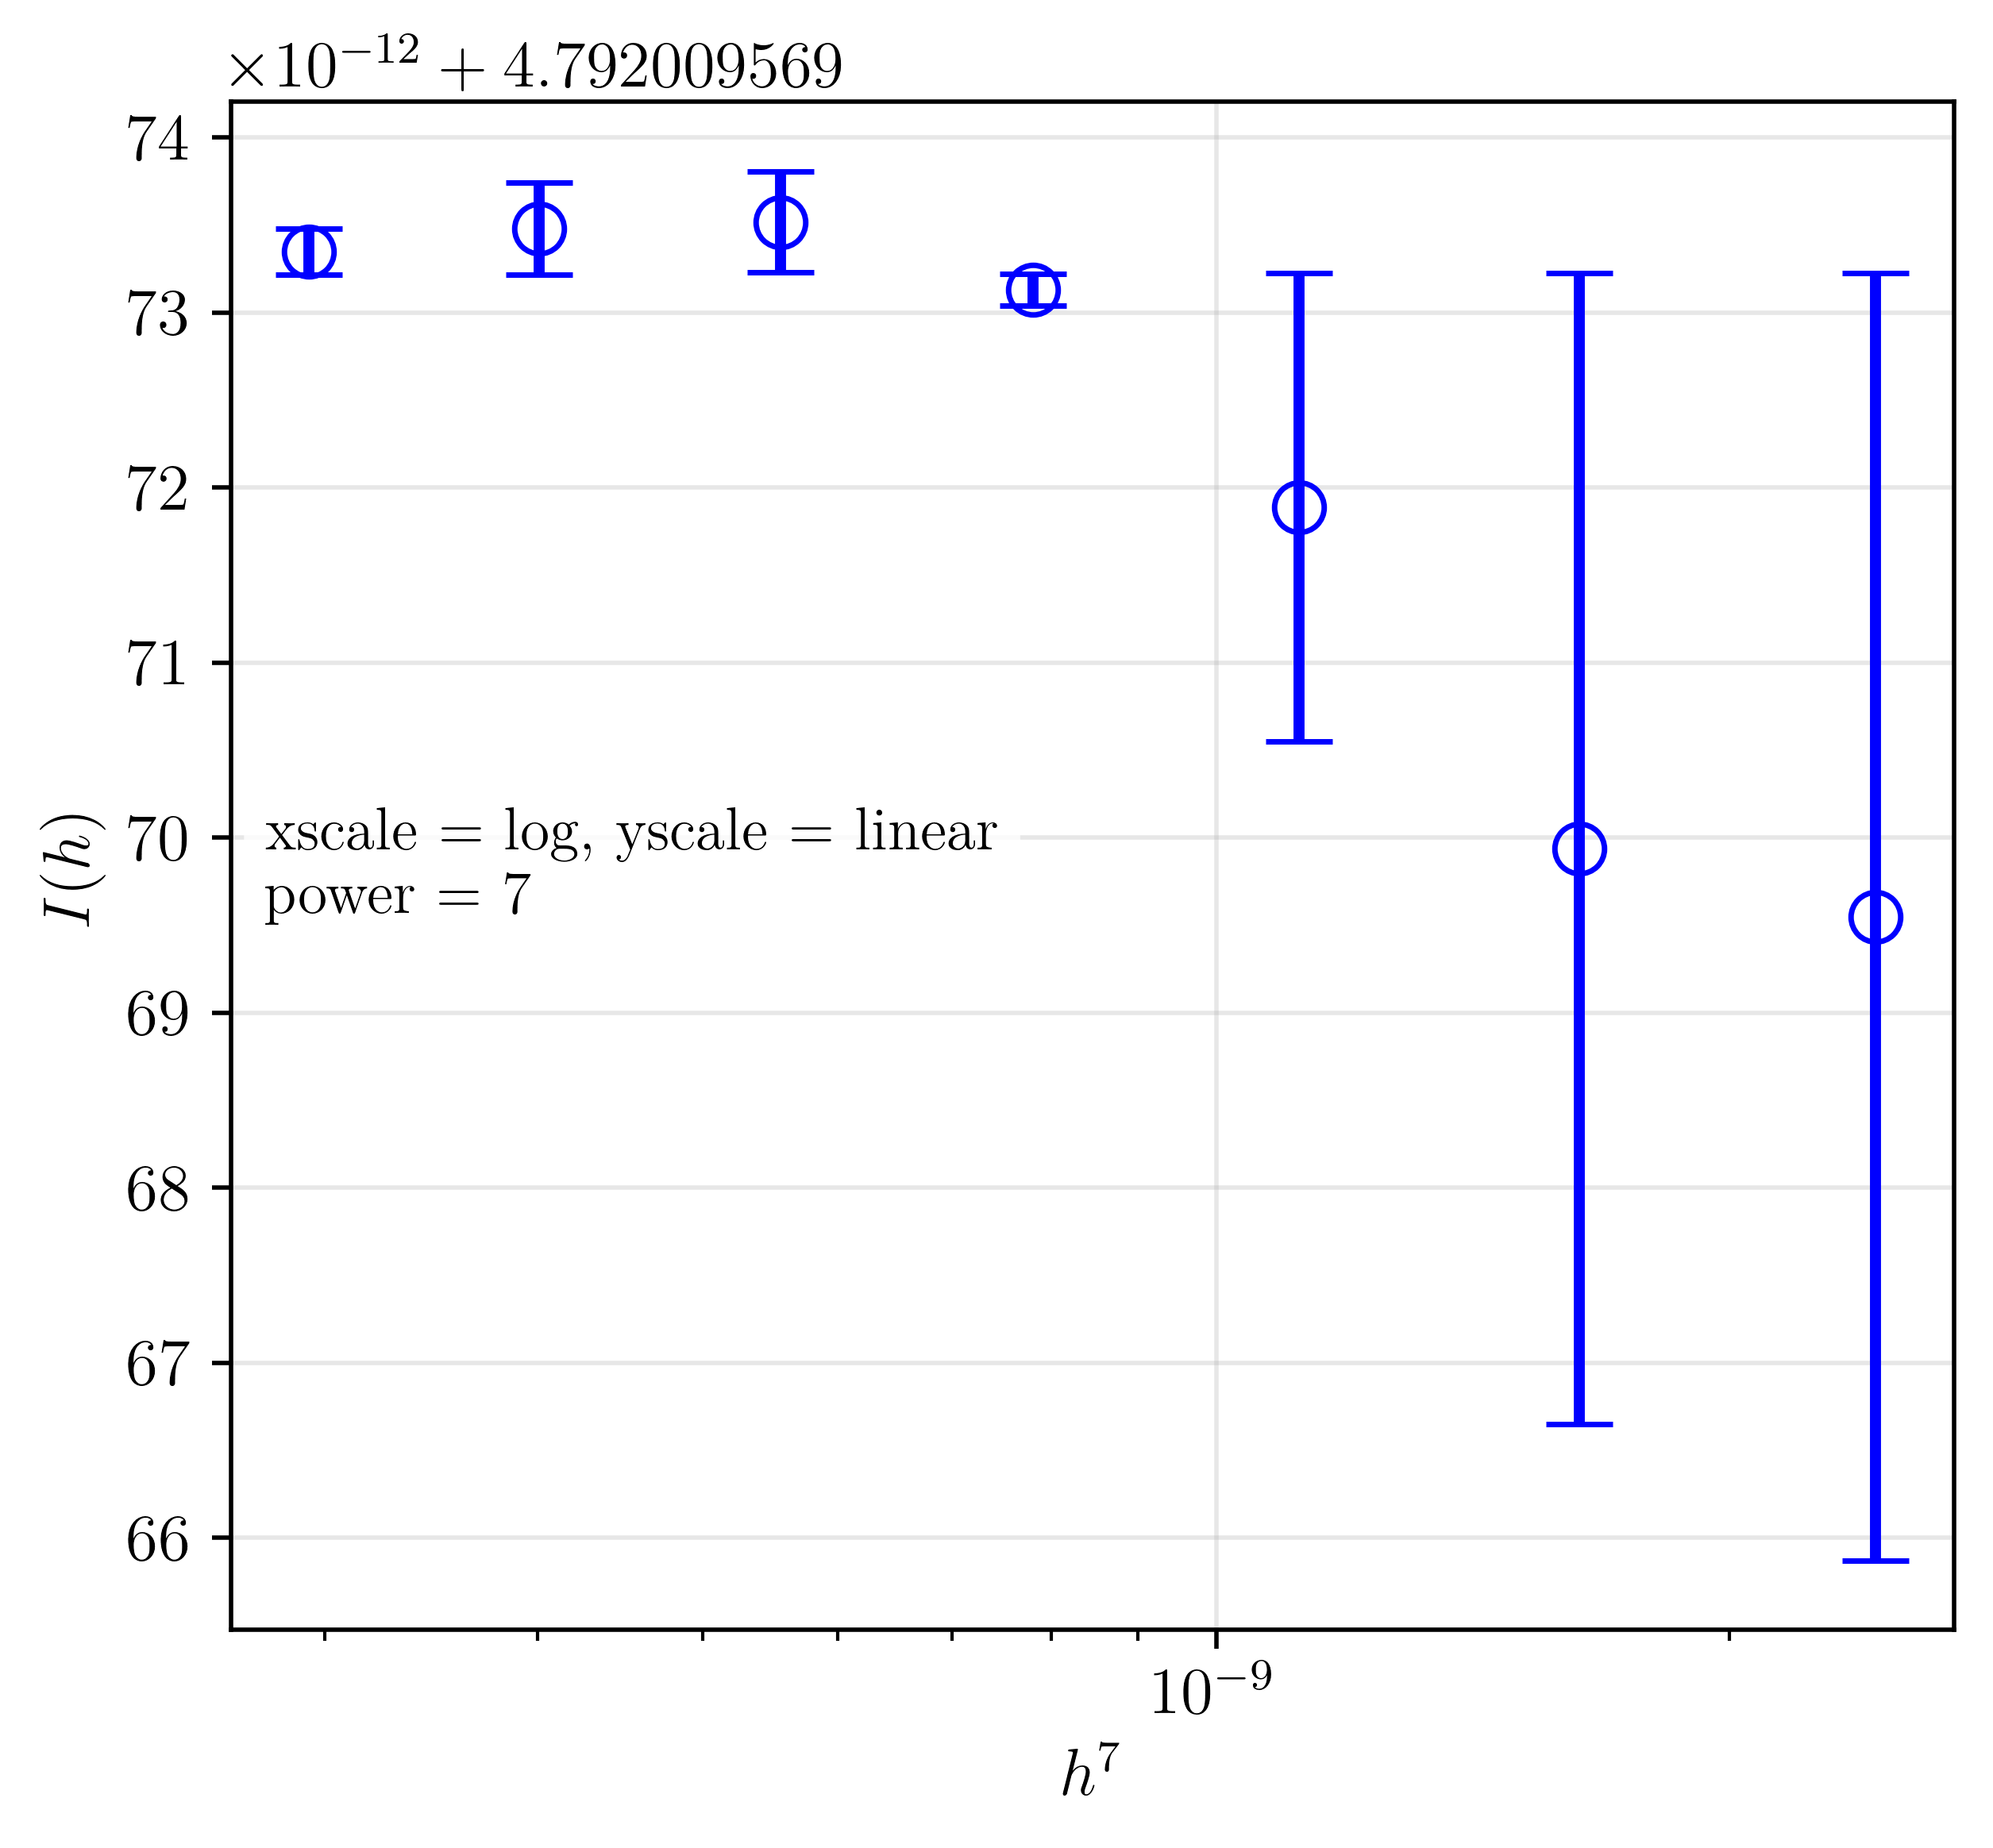

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `../samples/jld2/result_F0000_gauss_p12_LU_EXEX_N_17_18_19_20_21_22_23_gauss_p12_LU_EXEX_datapoints_hpow_7_log_linear-crop.pdf'.


In [5]:
h_power = 7
xscale = :log
yscale = :linear

plot_datapoints_result(
    run_result;
    name = run_result_file,
    h_power = h_power,
    xscale = xscale,
    yscale = yscale,
    rule = run_result.rule,
    boundary = run_result.boundary,
    figs_dir = save_path,
    save_file = true
)

## Step 4 :: Generate datapoints-only reports

At this stage we produce documentation artifacts based solely on the
raw data, without any fitted model.

These reports are useful for:

- preliminary validation,
- sharing intermediate results,
- archival of experimental conditions,
- reproducibility before model-dependent analysis.

In [6]:
write_convergence_summary_datapoints(
    run_result;
    name = run_result_file,
    h_power = h_power,
    xscale = xscale,
    yscale = yscale,
    rule = run_result.rule,
    boundary = run_result.boundary,
    format = :md,
    out_dir = save_path,
    save_file = true,
)

"# Convergence datapoints summary: ../samples/jld2/result_F0000_gauss_p12_LU_EXEX_N_17_18_19_20_21_22_23.jld2\n\n## Run configuration\n\n| Interval | Rule (Boundary) | Plot setup |\n|:--|:--|:--|\n| `[0.0, 1.0]` | `gauss_p12 (LU_EXEX)` | `h^7`, `log/linear` |\n\n## Quadrature estimates " ⋯ 218 bytes ⋯ "`1.118729e-09` | 4.7920095689719(13) |\n| `5.000000e-02` | `7.812500e-10` | 4.792009568973130(91) |\n| `4.761905e-02` | `5.552198e-10` | 4.79200956897352(29) |\n| `4.545455e-02` | `4.009048e-10` | 4.79200956897348(26) |\n| `4.347826e-02` | `2.937008e-10` | 4.79200956897335(13) |\n"

## Generate a datapoints-only internal note

Next we construct a self-contained internal note for the raw dataset
before any fit is applied.

This note collects the datapoints summary together with the saved
datapoints plot inside a buildable LaTeX project.

Such an artifact is useful when you want to archive or share the
pre-fit behavior of a numerical experiment independently of the
final extrapolation step.

In [7]:
note_info = write_convergence_internal_note_datapoints(
    run_result;
    name = run_result_file,
    h_power = h_power,
    xscale = xscale,
    yscale = yscale,
    rule = run_result.rule,
    boundary = run_result.boundary,
    out_dir = save_path,
    save_file = true,
    try_build_pdf = true,
    move_existing_plots = true,
)

pdflatex inote_summary_result_F0000_gauss_p12_LU_EXEX_N_17_18_19_20_21_22_23_hpow_7_log_linear
This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) (preloaded format=pdflatex)
 restricted \write18 enabled.
entering extended mode

(./inote_summary_result_F0000_gauss_p12_LU_EXEX_N_17_18_19_20_21_22_23_hpow_7_l
og_linear.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>

(/home/benjamin/work.lib/texlive/2025/texmf-dist/tex/latex/revtex/revtex4-2.cls
Document Class: revtex4-2 2022/06/05 4.2f (https://journals.aps.org/revtex/ for
 documentation)
ltxutil[2022/06/05 4.2f utilities package (portions licensed from W. E. Baxter 
web at superscript.com)]
ltxfront[2022/06/05 4.2f frontmatter package (AO,DPC,MD)]
ltxgrid[2022/06/05 4.2f page grid package (portions licensed from W. E. Baxter 
web at superscript.com)]

Class revtex4-2 Warning: No Society specified, using default society aps.

(/home/benjamin/work.lib/texlive/2025/texmf-dist/tex/latex/revtex/aps4-2.rtx)
(/home/benj

(note_dir = "../samples/jld2/inote_summary_result_F0000_gauss_p12_LU_EXEX_N_17_18_19_20_21_22_23_hpow_7_log_linear", figs_dir = "../samples/jld2/inote_summary_result_F0000_gauss_p12_LU_EXEX_N_17_18_19_20_21_22_23_hpow_7_log_linear/figs", summary_tex_path = "../samples/jld2/inote_summary_result_F0000_gauss_p12_LU_EXEX_N_17_18_19_20_21_22_23_hpow_7_log_linear/summary_result_F0000_gauss_p12_LU_EXEX_N_17_18_19_20_21_22_23_hpow_7_log_linear_table.tex", fig_tex_path = "../samples/jld2/inote_summary_result_F0000_gauss_p12_LU_EXEX_N_17_18_19_20_21_22_23_hpow_7_log_linear/summary_result_F0000_gauss_p12_LU_EXEX_N_17_18_19_20_21_22_23_hpow_7_log_linear_figs.tex", master_tex_path = "../samples/jld2/inote_summary_result_F0000_gauss_p12_LU_EXEX_N_17_18_19_20_21_22_23_hpow_7_log_linear/inote_summary_result_F0000_gauss_p12_LU_EXEX_N_17_18_19_20_21_22_23_hpow_7_log_linear.tex", makefile_path = "../samples/jld2/inote_summary_result_F0000_gauss_p12_LU_EXEX_N_17_18_19_20_21_22_23_hpow_7_log_linear/Makefil

### Tag outputs for Lesson 6

To avoid overwriting files generated in previous lessons,
we append a lesson-specific suffix to the result name.

This modified identifier will be used by downstream functions
(such as plotting or report generation) when constructing
output filenames.

In [8]:
result_string = "lesson6_" * result_string

"lesson6_F0000"

## Step 5 :: Perform continuum extrapolation

We now estimate the continuum limit \( h \to 0 \) using a weighted
least-\(\chi^2\) fit.

The fitted model uses the error-scale information generated earlier to
construct statistically meaningful weights across resolutions.

Only a subset of the lowest-order terms may be retained to stabilize
the fit.

In [9]:
fit_nterms = 2
fit_nerr_terms = 3

fit_result = least_chi_square_fit(
    run_result; 
    nterms=fit_nterms, 
    ff_shift=0, 
    nerr_terms=fit_nerr_terms
)

[2026-03-18 23:30:48.477] residual ks (backend) = [7, 9], fit powers (h^p), ff_shift=0 = [7]


(estimate = 4.7920095689736, error_estimate = 2.0076933334491707e-13, params = [4.7920095689736, -0.0006110034707553211], param_errors = [2.0076933334491707e-13, 0.000309523852199447], cov = [4.030832521176243e-26 -5.828170227480736e-17; -5.828170227480737e-17 9.580501508038511e-8], powers = [0, 7], chisq = 3.06101560833973, redchisq = 0.612203121667946, dof = 5)

## Step 6 :: Inspect fitted parameters

The printed output summarizes the estimated continuum value and the
coefficients of the asymptotic expansion.

This information can be used to assess:

- the stability of the fit,
- the magnitude of higher-order corrections,
- consistency with theoretical expectations.

In [10]:
print_fit_result(fit_result)

[2026-03-18 23:30:50.227]            λ_0 = 4.79200956897360(20)
[2026-03-18 23:30:50.227]            λ_1 = -0.00061(31)
[2026-03-18 23:30:50.227] 
[2026-03-18 23:30:50.227] Chi^2 / d.o.f. = 3.061015608340e+00 / 5 = 6.122031216679e-01
[2026-03-18 23:30:50.227] Result (h→0)   = 4.79200956897360(20)
[2026-03-18 23:30:50.227] 


## Step 7 :: Visualize fitted convergence

The convergence plot overlays the fitted model on the raw datapoints
and includes uncertainty bands derived from the covariance matrix.

This visualization provides an intuitive check that the model captures
the observed scaling behavior.

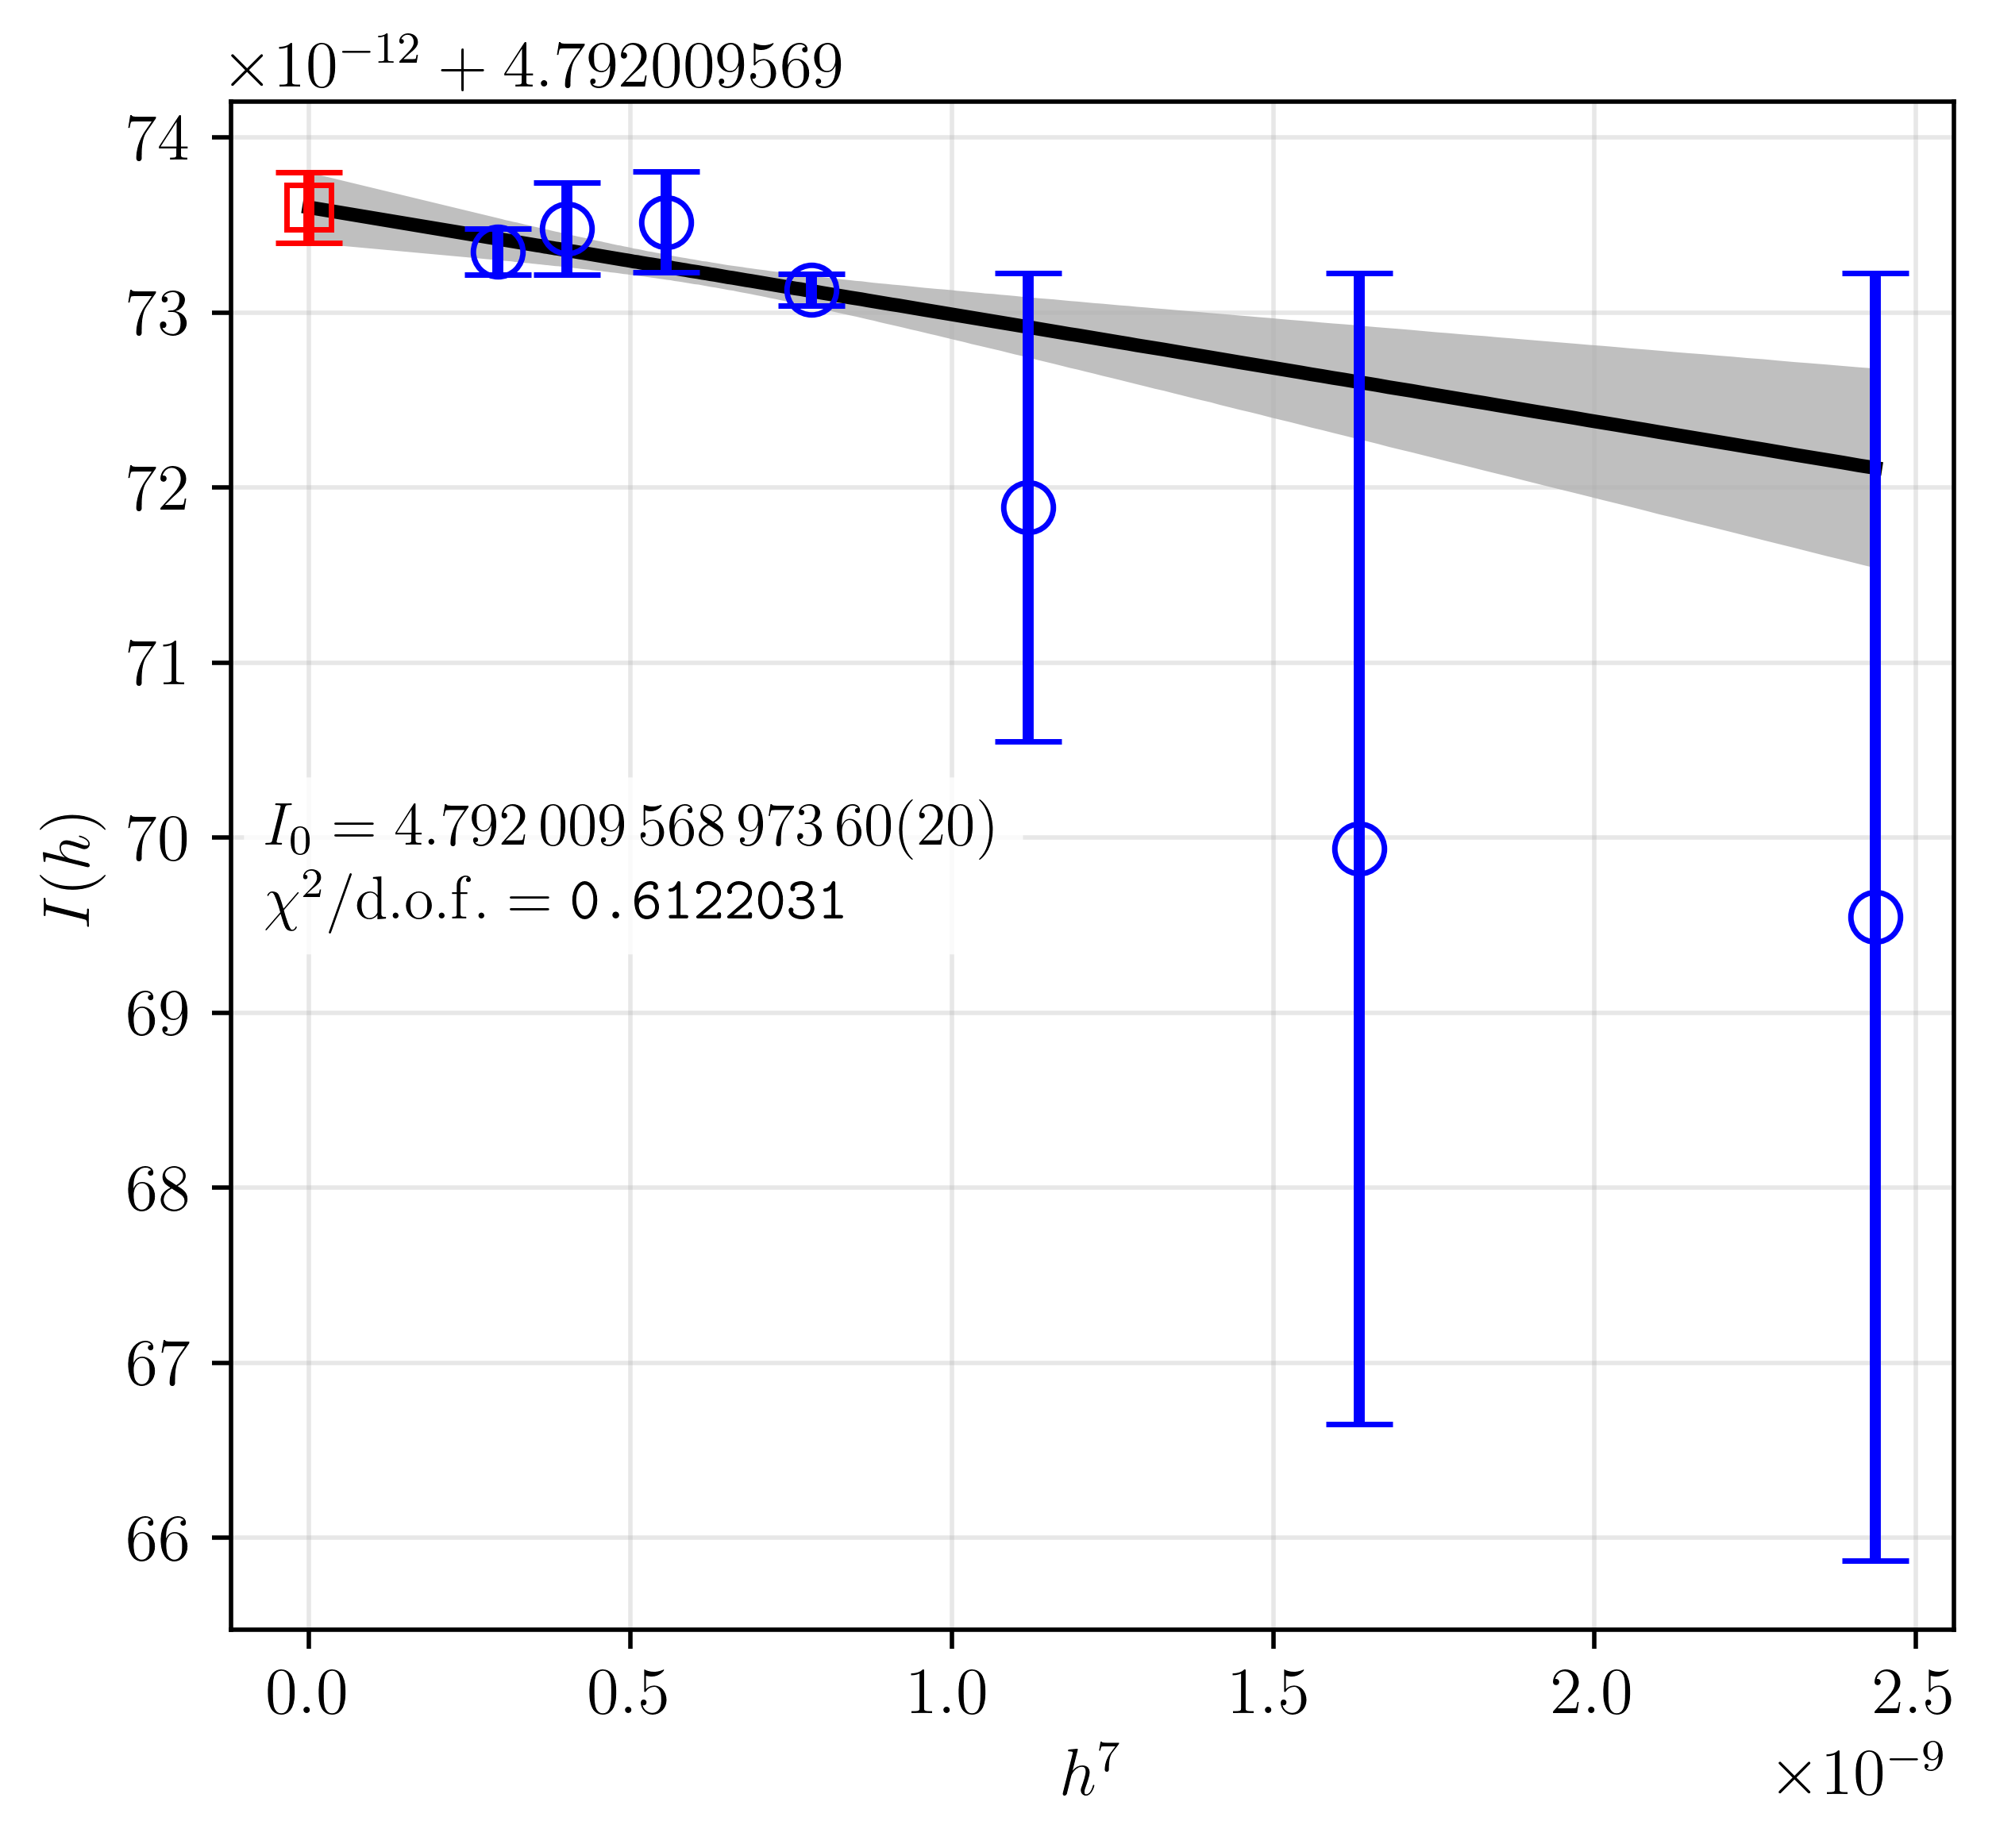

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `../samples/jld2/result_lesson6_F0000_gauss_p12_LU_EXEX_extrap-crop.pdf'.
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `../samples/jld2/result_lesson6_F0000_gauss_p12_LU_EXEX_reldiff-crop.pdf'.


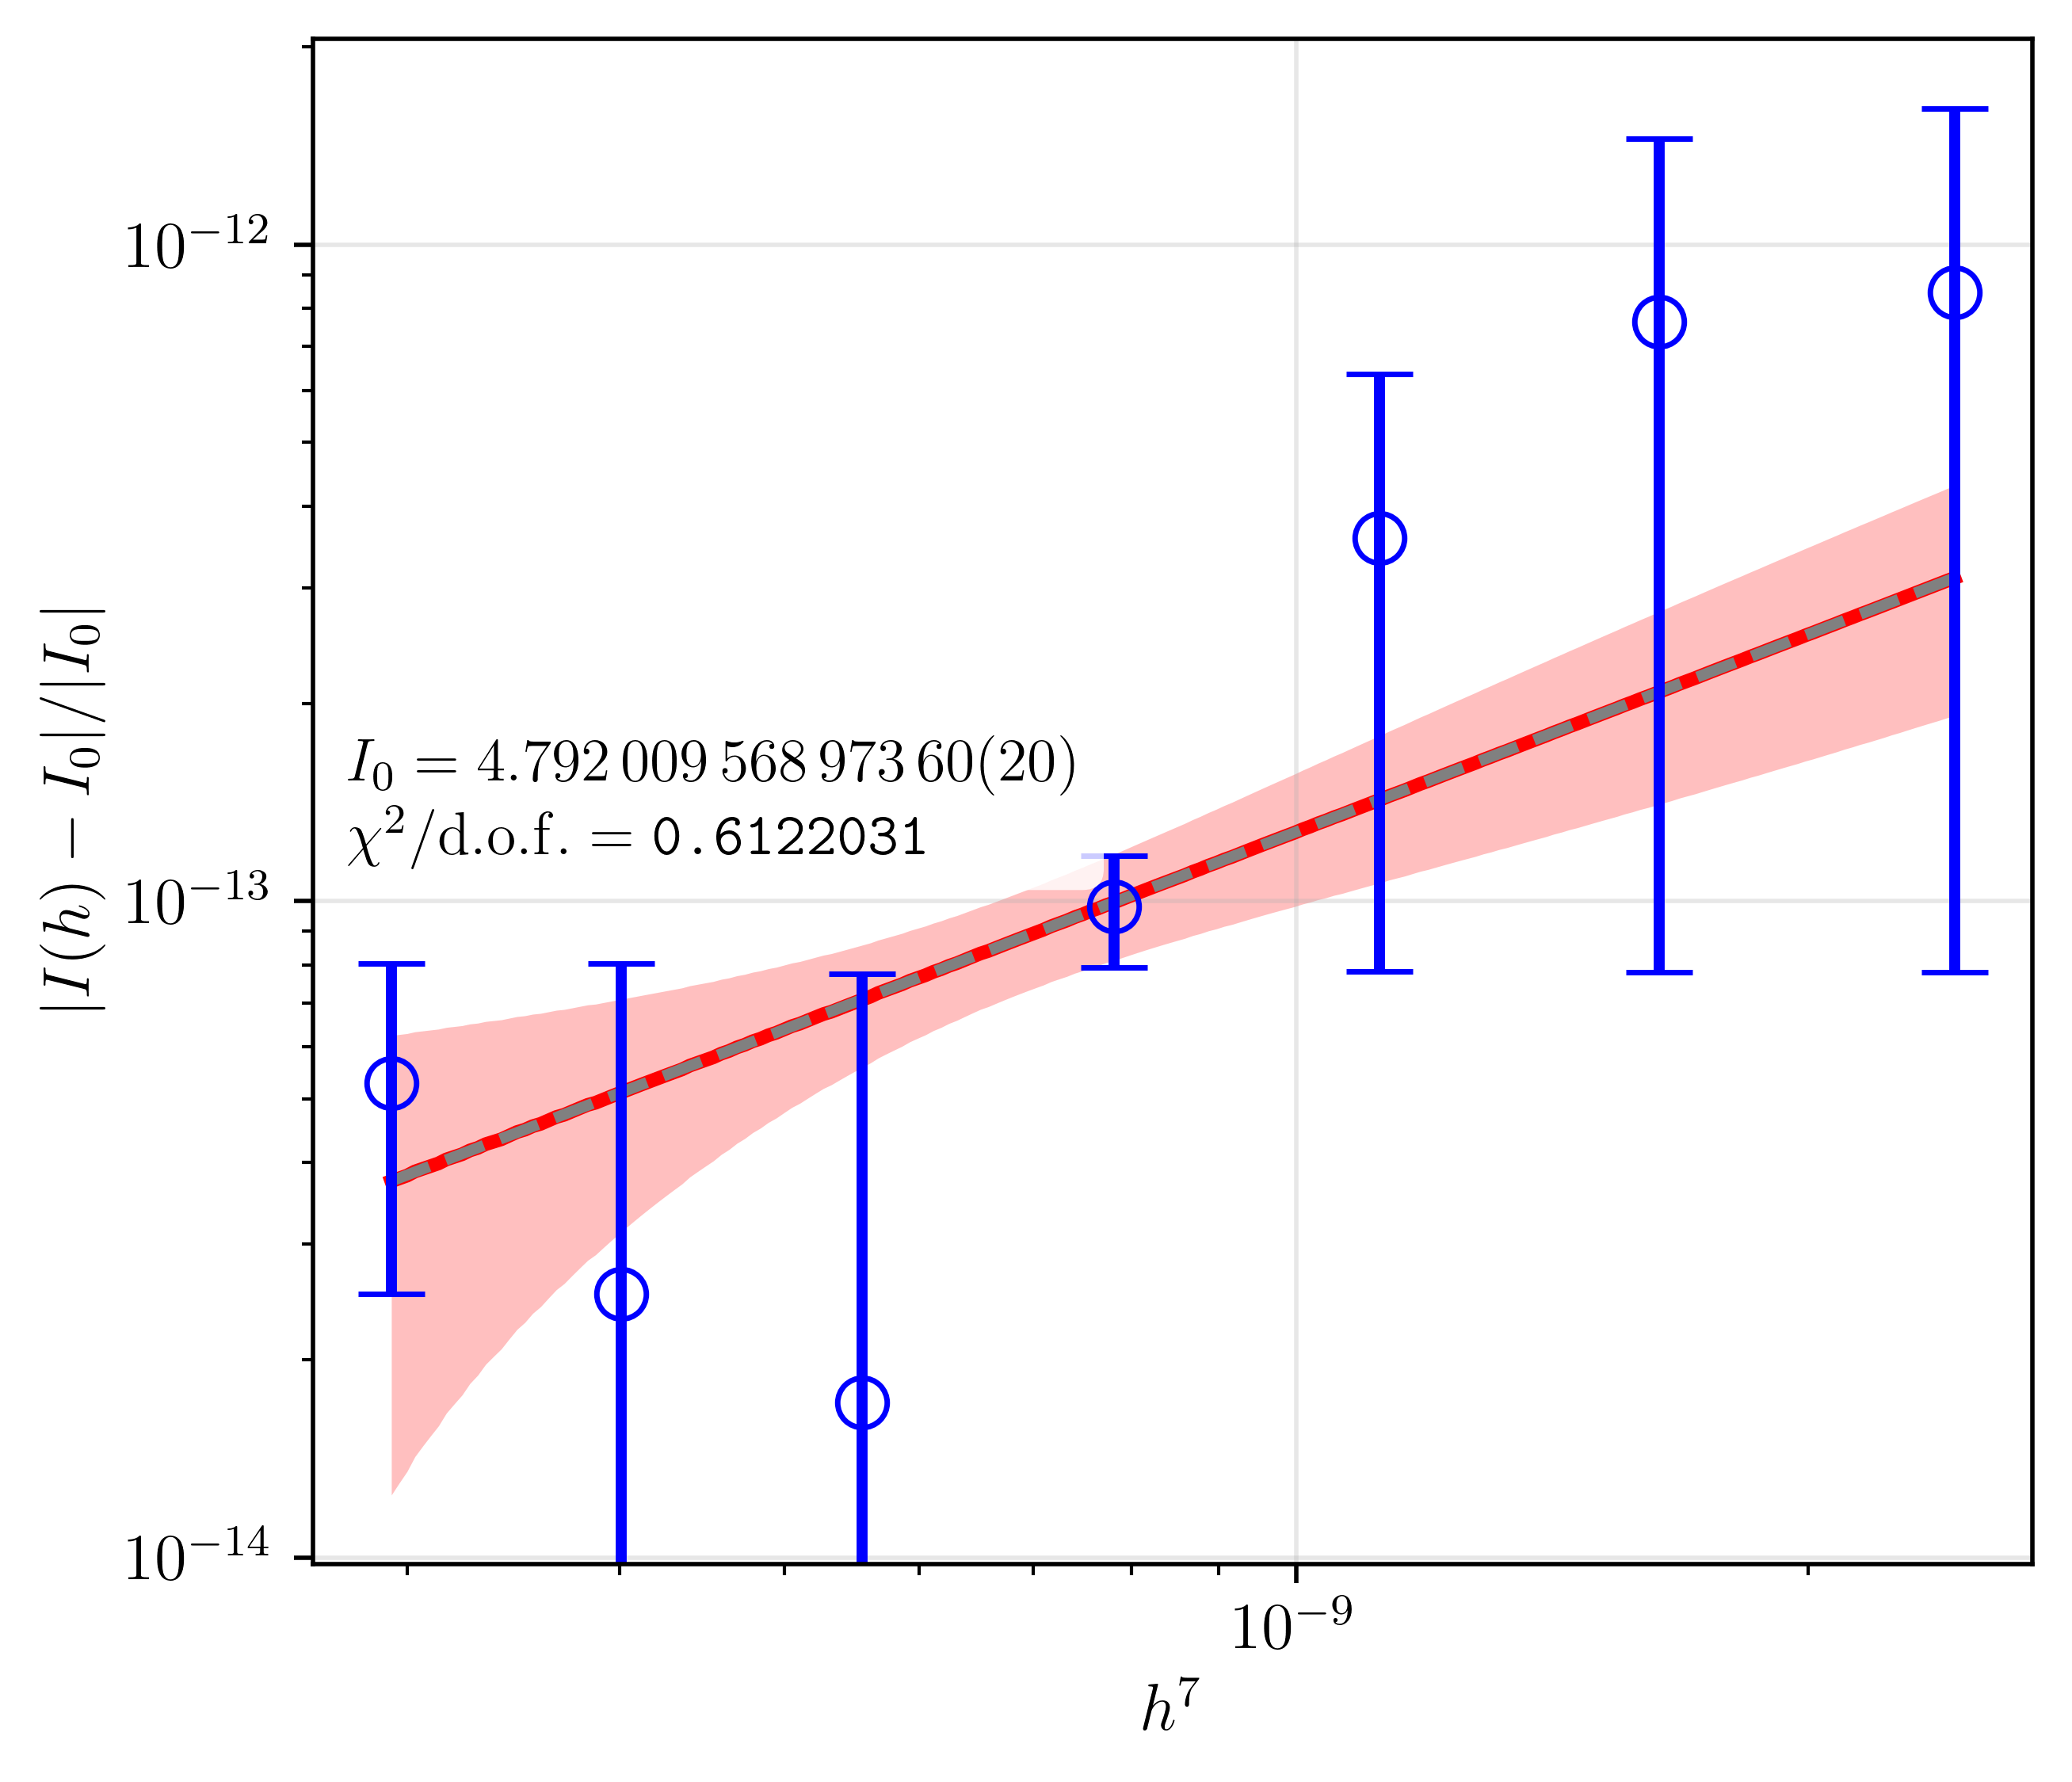

In [11]:
plot_convergence_result(
    run_result, 
    fit_result;
    name=result_string,
    figs_dir=save_path,
    save_file=true
)

## Step 8 :: Produce fit-aware documentation

Finally, we generate summaries and internal-note artifacts that
incorporate the fitted results.

These outputs are designed to be directly usable in technical reports
or publications, ensuring that the numerical study is fully
reproducible.

In [12]:
write_convergence_summary(
    run_result,
    fit_result;
    name = result_string,
    format = :md,
    out_dir = save_path,
    save_file = true,
    nterms=fit_nterms, 
    nerr_terms=fit_nerr_terms,
)

"# Convergence summary: lesson6_F0000\n\n## Run configuration\n\n| Interval | Rule (Boundary) | Number of error terms |\n|:--|:--|:--|\n| `[0.0, 1.0]` | `gauss_p12 (LU_EXEX)` | `3` |\n\n## Quadrature estimates and uncertainties for different step sizes\n\n| \$h\$ | \$h^7\$ | \$I(h)\$ |\n|:--|:--|:-" ⋯ 464 bytes ⋯ "7360(20)** |\n\n## Least-chi-square fit results for extrapolation to \$h \\to 0\$\n\n```math\nf(h) = \\lambda_0 + \\lambda_1 h^{7}\n```\n\n| parameter | fit result |\n|:--|:--|\n| \$\\lambda_0\$ | **4.79200956897360(20)** |\n| \$\\lambda_1\$ | -0.00061(31) |\n| \$\\chi^2 / \\text{d.o.f.}\$ | `6.122031e-01` |\n"

## Build the final internal note

Finally, we generate a complete internal note for the fitted analysis.

This note combines

- the fit-aware summary tables,
- the saved convergence figures,
- a REVTeX-based master document,
- and a reproducible build structure.

At this point the workflow has produced both

- pre-fit reporting artifacts, and
- final fit-based reporting artifacts

from a single numerical experiment.

In [13]:
note_info = write_convergence_internal_note(
    run_result,
    fit_result;
    name = result_string,
    rule = run_result.rule,
    boundary = run_result.boundary,
    out_dir = save_path,
    save_file = true,
    try_build_pdf = true,
    move_existing_plots = true,
    nterms=fit_nterms, 
    nerr_terms=fit_nerr_terms,
    # author = "Benjamin J. Choi",
    # affiliation = "Center for Computational Sciences, University of Tsukuba, 1-1-1 Tennodai, Tsukuba, Ibaraki 305-8577, Japan",
    # abstract_text = "This note summarizes the convergence study and fitted extrapolation result."
)

pdflatex inote_summary_lesson6_F0000_gauss_p12_LU_EXEX_ff_2_er_3
This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) (preloaded format=pdflatex)
 restricted \write18 enabled.
entering extended mode
(./inote_summary_lesson6_F0000_gauss_p12_LU_EXEX_ff_2_er_3.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>

(/home/benjamin/work.lib/texlive/2025/texmf-dist/tex/latex/revtex/revtex4-2.cls
Document Class: revtex4-2 2022/06/05 4.2f (https://journals.aps.org/revtex/ for
 documentation)
ltxutil[2022/06/05 4.2f utilities package (portions licensed from W. E. Baxter 
web at superscript.com)]
ltxfront[2022/06/05 4.2f frontmatter package (AO,DPC,MD)]
ltxgrid[2022/06/05 4.2f page grid package (portions licensed from W. E. Baxter 
web at superscript.com)]

Class revtex4-2 Warning: No Society specified, using default society aps.

(/home/benjamin/work.lib/texlive/2025/texmf-dist/tex/latex/revtex/aps4-2.rtx)
(/home/benjamin/work.lib/texlive/2025/texmf-dist/tex/latex/revtex/aps12pt

(note_dir = "../samples/jld2/inote_summary_lesson6_F0000_gauss_p12_LU_EXEX_ff_2_er_3", figs_dir = "../samples/jld2/inote_summary_lesson6_F0000_gauss_p12_LU_EXEX_ff_2_er_3/figs", summary_tex_path = "../samples/jld2/inote_summary_lesson6_F0000_gauss_p12_LU_EXEX_ff_2_er_3/summary_lesson6_F0000_gauss_p12_LU_EXEX_ff_2_er_3_table.tex", fig_tex_path = "../samples/jld2/inote_summary_lesson6_F0000_gauss_p12_LU_EXEX_ff_2_er_3/summary_lesson6_F0000_gauss_p12_LU_EXEX_ff_2_er_3_figs.tex", master_tex_path = "../samples/jld2/inote_summary_lesson6_F0000_gauss_p12_LU_EXEX_ff_2_er_3/inote_summary_lesson6_F0000_gauss_p12_LU_EXEX_ff_2_er_3.tex", makefile_path = "../samples/jld2/inote_summary_lesson6_F0000_gauss_p12_LU_EXEX_ff_2_er_3/Makefile", moved_plots = ["../samples/jld2/inote_summary_lesson6_F0000_gauss_p12_LU_EXEX_ff_2_er_3/figs/result_lesson6_F0000_gauss_p12_LU_EXEX_extrap.pdf", "../samples/jld2/inote_summary_lesson6_F0000_gauss_p12_LU_EXEX_ff_2_er_3/figs/result_lesson6_F0000_gauss_p12_LU_EXEX_reld

## Summary

In this notebook we demonstrated a full research-style reporting
workflow using `Maranatha.jl`.

Starting from a realistic quadrature setup for a challenging integrand,
we performed:

1. definition and execution of a multi-resolution experiment,
2. inspection of raw convergence datapoints,
3. generation of datapoints-only documentation,
4. continuum extrapolation via least-\(\chi^2\) fitting,
5. visualization of fitted convergence behavior,
6. production of fit-aware summaries and internal notes.

This workflow illustrates how a single numerical experiment can be
developed into a complete, reproducible research package covering both

- the pre-fit validation stage, and
- the final model-based analysis stage.

Such a pipeline is particularly valuable when results must be archived,
shared with collaborators, or incorporated into formal reports.